## Result Graphs

### This script generates result graphs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../../results/results.csv") 

In [2]:
MODELS = {
    "iam": {
        "base": ("microsoft/trocr-base-handwritten", "IAM Basismodell"),
        "awgn": ("iam_awgn", "IAM AWGN-Modell"),
        "blur": ("iam_blur", "IAM Unschärfe-Modell"),
        "jpeg_compression": ("iam_jpeg_compression", "IAM JPEG-Modell"),
        "downscale": ("iam_downscale", "IAM Downscale-Modell"),
        "combo": ("iam_combo", "IAM Modell mit kombinierten Degradierungen"),
        "mixed": ("iam_mixed", "IAM Modell mit gemischten Degradierungen"),
    },

    "rimes": {
        "base": ("RIMES-base", "RIMES Basismodell"),
        "awgn": ("RIMES_awgn", "RIMES AWGN-Modell"),
        "blur": ("RIMES_blur", "RIMES Unschärfe-Modell"),
        "jpeg_compression": ("RIMES_jpeg_compression", "RIMES JPEG-Modell"),
        "downscale": ("RIMES_downscale", "RIMES Downscale-Modell"),
        "combo": ("RIMES_combo", "RIMES Modell mit kombinierten Degradierungen"),
        "mixed": ("RIMES_mixed", "RIMES Modell mit gemischten Degradierungen"),
    },

    "catmus": {
        "base": ("CATMuS_base", "CATMuS Basismodell"),
        "awgn": ("CATMuS_awgn", "CATMuS AWGN-Modell"),
        "blur": ("CATMuS_blur", "CATMuS Unschärfe-Modell"),
        "jpeg_compression": ("CATMuS_jpeg_compression", "CATMuS JPEG-Modell"),
        "downscale": ("CATMuS_downscale", "CATMuS Downscale-Modell"),
    },
}

DEGRADATIONS = {
    "awgn": [50, 100, 150, 200, 250],
    "blur": [1.0, 2.0, 3.0, 4.0, 5.0],
    "jpeg_compression": [10, 6, 3, 1],
    "downscale": [35, 30, 25, 20, 15],
    "combo": [1, 2, 3, 4, 5],
}

DEGRADATION_LABELS = {
    "awgn": "AWGN-Rauschen",
    "blur": "Unschärfe",
    "jpeg_compression": "JPEG-Kompression",
    "downscale": "Herunterskalierung",
    "combo": "Kombinierte Degradierungen",
}

METRIC_LABELS = {
    "cer": "Zeichenfehlerrate (CER) [%]",
    "wer": "Wortfehlerrate (WER) [%]",
}

DATASET_COLORS = {
    "iam": "tab:blue",
    "rimes": "tab:orange",
    "catmus": "tab:green",
}

MODEL_COLORS = {
    "base": "black",
    "awgn": "tab:blue",
    "blur": "tab:orange",
    "jpeg_compression": "tab:green",
    "downscale": "tab:red",
    "combo": "tab:purple",
    "mixed": "tab:brown",
}

### Help function to render result graph for a method and metric combo

In [4]:
def render_graph(
    degradation,
    group,
    title=None,
    x_label="Degradationsintensität"
):
    if degradation not in DEGRADATIONS:
        raise ValueError(f"Unbekannte Degradationsmethode: {degradation}")

    if group != "matched" and group not in MODELS:
        raise ValueError(
            f"Gruppe muss 'matched' oder eine der folgenden sein: "
            f"{list(MODELS.keys())}"
        )

    intensities = DEGRADATIONS[degradation]

    # Bezeichnung für undegradiertes Bild
    if degradation in ["jpeg_compression", "downscale"]:
        x_labels = ["Originalbild"] + intensities
    else:
        x_labels = ["0"] + intensities

    x = range(len(x_labels))

    # --------------------------------------------------
    # Modelle auswählen
    # --------------------------------------------------

    models_to_plot = []

    if group == "matched":
        # Nur Basismodell jedes Datensatzes
        for dataset, models in MODELS.items():

            if "base" not in models:
                continue

            model, label = models["base"]

            models_to_plot.append({
                "model": model,
                "label": label,
                "color": DATASET_COLORS[dataset],
                "linestyle": "-",
            })

    elif group == "catmus":
        # CATMuS Basismodell
        model, label = MODELS["catmus"]["base"]

        models_to_plot.append({
            "model": model,
            "label": label,
            "color": MODEL_COLORS["base"],
            "linestyle": "-",
        })

        # Passendes CATMuS-Modell, falls vorhanden
        if degradation in MODELS["catmus"]:
            model, label = MODELS["catmus"][degradation]

            models_to_plot.append({
                "model": model,
                "label": label,
                "color": MODEL_COLORS[degradation],
                "linestyle": "-",
            })

    else:
        # Alle Modelle des gewählten Datensatzes
        for model_type, (model, label) in MODELS[group].items():

            # Basismodell und passendes Modell durchgezogen,
            # alle anderen gestrichelt
            if model_type == "base" or model_type == degradation:
                linestyle = "-"
            else:
                linestyle = "--"

            models_to_plot.append({
                "model": model,
                "label": label,
                "color": MODEL_COLORS[model_type],
                "linestyle": linestyle,
            })

    # --------------------------------------------------
    # CER und WER nebeneinander
    # --------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, metric in zip(axes, ["cer", "wer"]):

        for model_info in models_to_plot:

            model = model_info["model"]

            # Ergebnis ohne Degradation
            base_row = df[
                (df["method"] == "none")
                & (df["model"] == model)
            ]

            # Ergebnisse für gewählte Degradation
            degraded_df = df[
                (df["method"] == degradation)
                & (df["model"] == model)
            ].copy()

            if degraded_df.empty:
                continue

            degraded_df["intensity"] = pd.to_numeric(
                degraded_df["intensity"]
            )

            degraded_df = (
                degraded_df
                .set_index("intensity")
                .reindex(intensities)
            )

            # Undegradiertes Ergebnis + degradierte Ergebnisse
            y = []

            if not base_row.empty:
                y.append(base_row.iloc[0][metric] * 100)
            else:
                y.append(float("nan"))

            y.extend(
                (degraded_df[metric] * 100).tolist()
            )

            ax.plot(
                x,
                y,
                color=model_info["color"],
                linestyle=model_info["linestyle"],
                marker="o",
                label=model_info["label"]
            )

        ax.set_xticks(list(x))
        ax.set_xticklabels(x_labels)

        ax.set_xlabel(x_label)
        ax.set_ylabel(f"{metric.upper()} [%]")
        ax.set_title(metric.upper())

        ax.grid(alpha=0.3)

    # --------------------------------------------------
    # Gemeinsamer Titel
    # --------------------------------------------------

    if title is None:
        title = DEGRADATION_LABELS[degradation]

    fig.suptitle(title, fontsize=14)

    axes[1].legend(
        title="Modelle",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

### Graphs

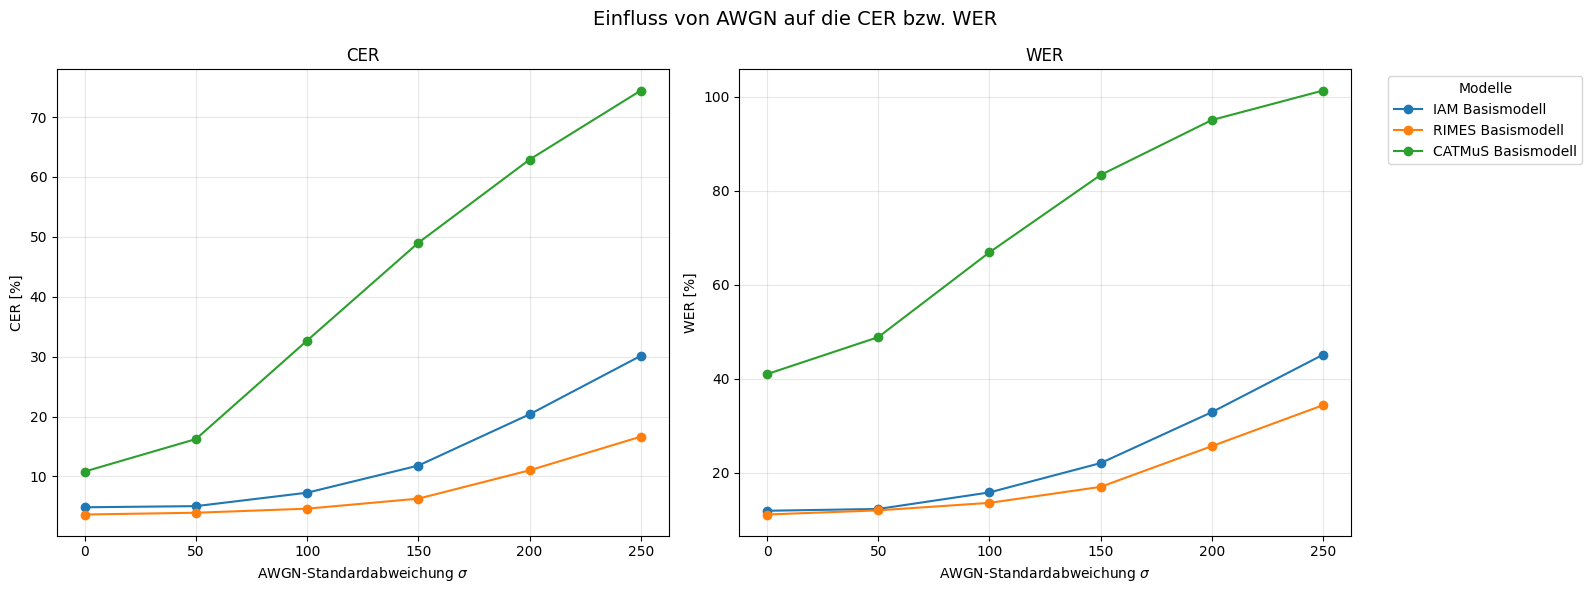

In [14]:
render_graph(
    "awgn",
    "matched",
    title="Einfluss von AWGN auf die CER bzw. WER",
    x_label=r"AWGN-Standardabweichung $\sigma$",
)

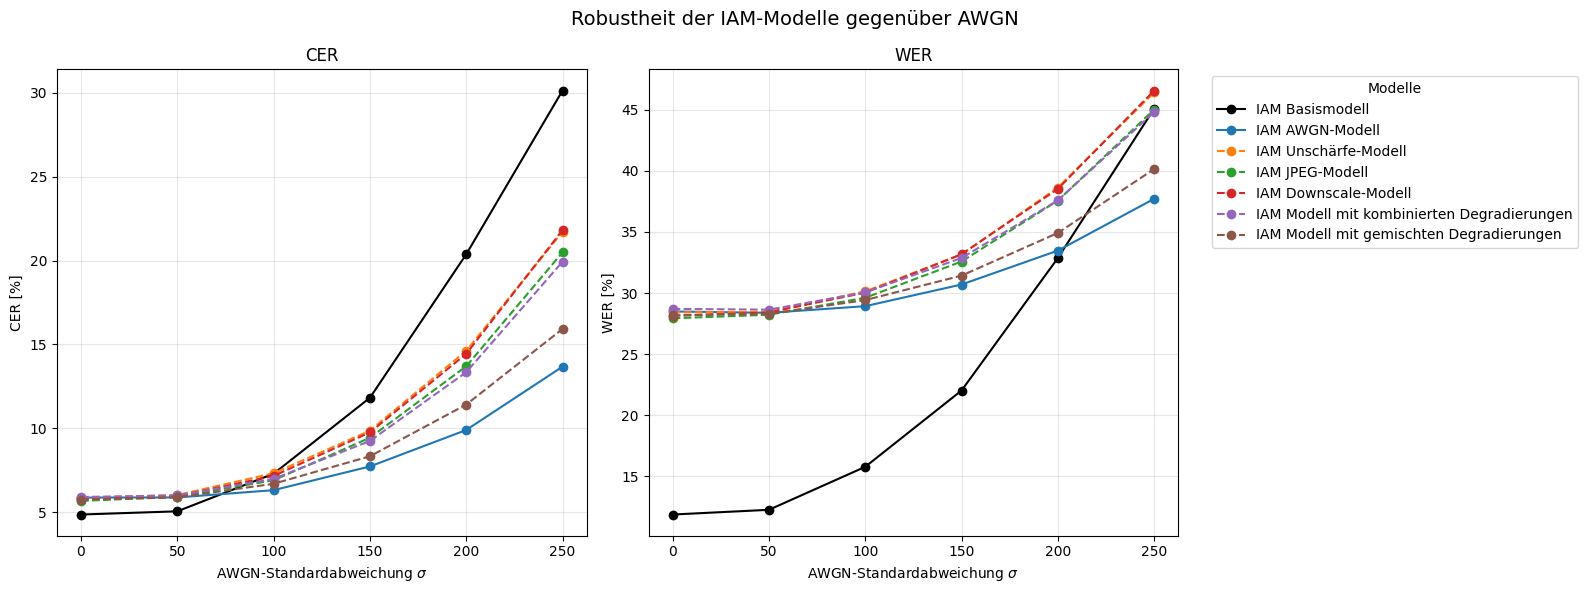

In [4]:
render_graph(
    "awgn",
    "iam",
    title="Robustheit der IAM-Modelle gegenüber AWGN",
    x_label=r"AWGN-Standardabweichung $\sigma$",
)

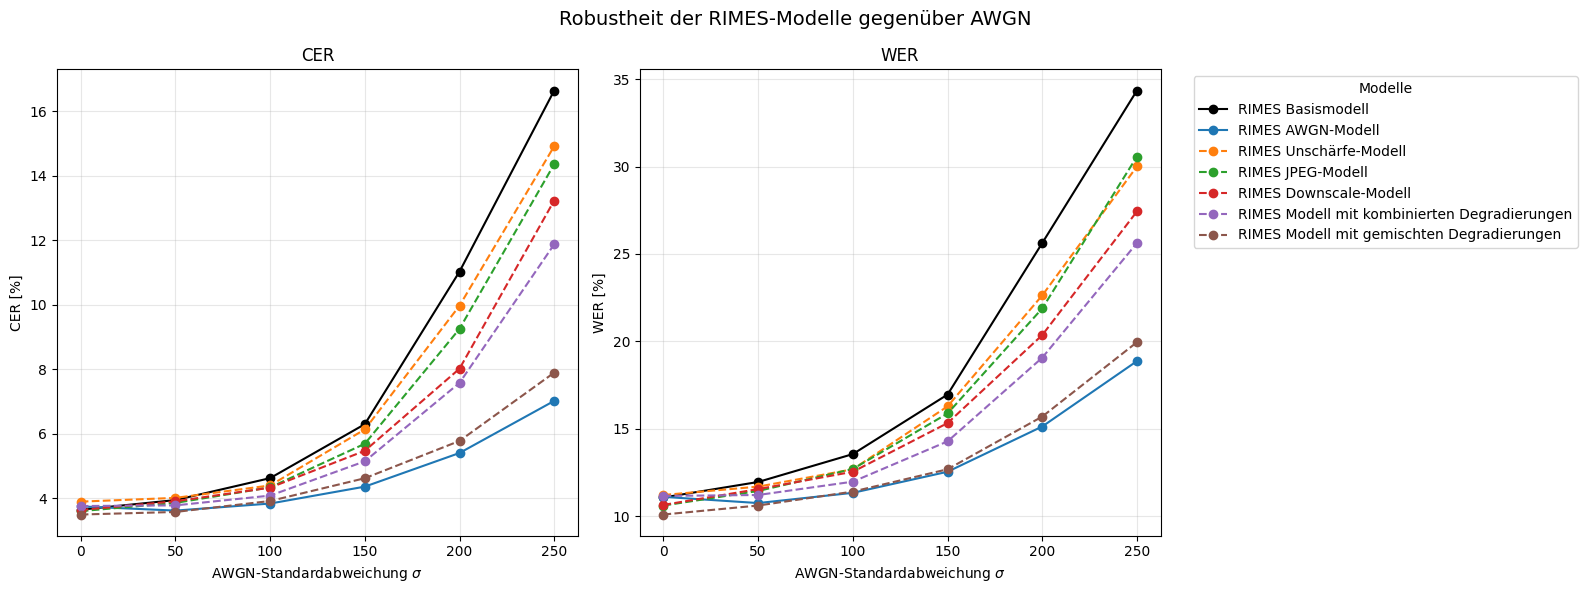

In [5]:
render_graph(
    "awgn",
    "rimes",
    title="Robustheit der RIMES-Modelle gegenüber AWGN",
    x_label=r"AWGN-Standardabweichung $\sigma$",
)

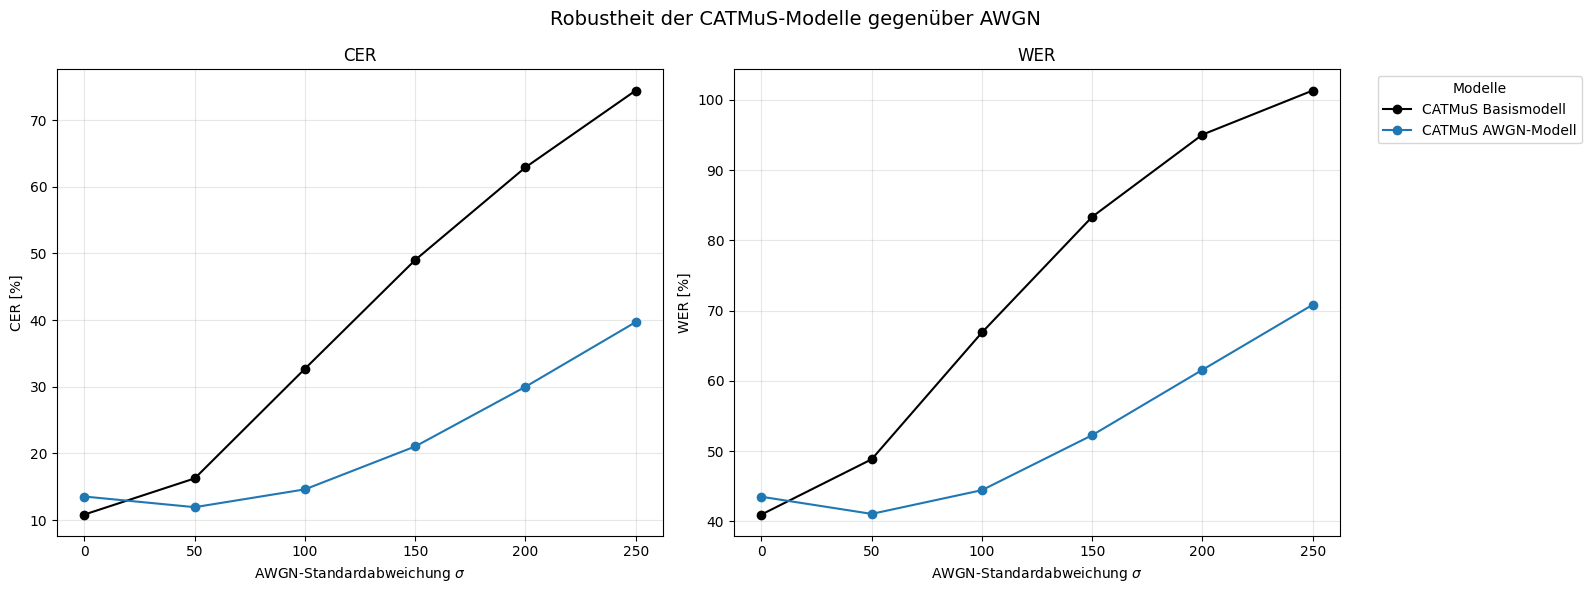

In [4]:
render_graph(
    "awgn",
    "catmus",
    title="Robustheit der CATMuS-Modelle gegenüber AWGN",
    x_label=r"AWGN-Standardabweichung $\sigma$",
)

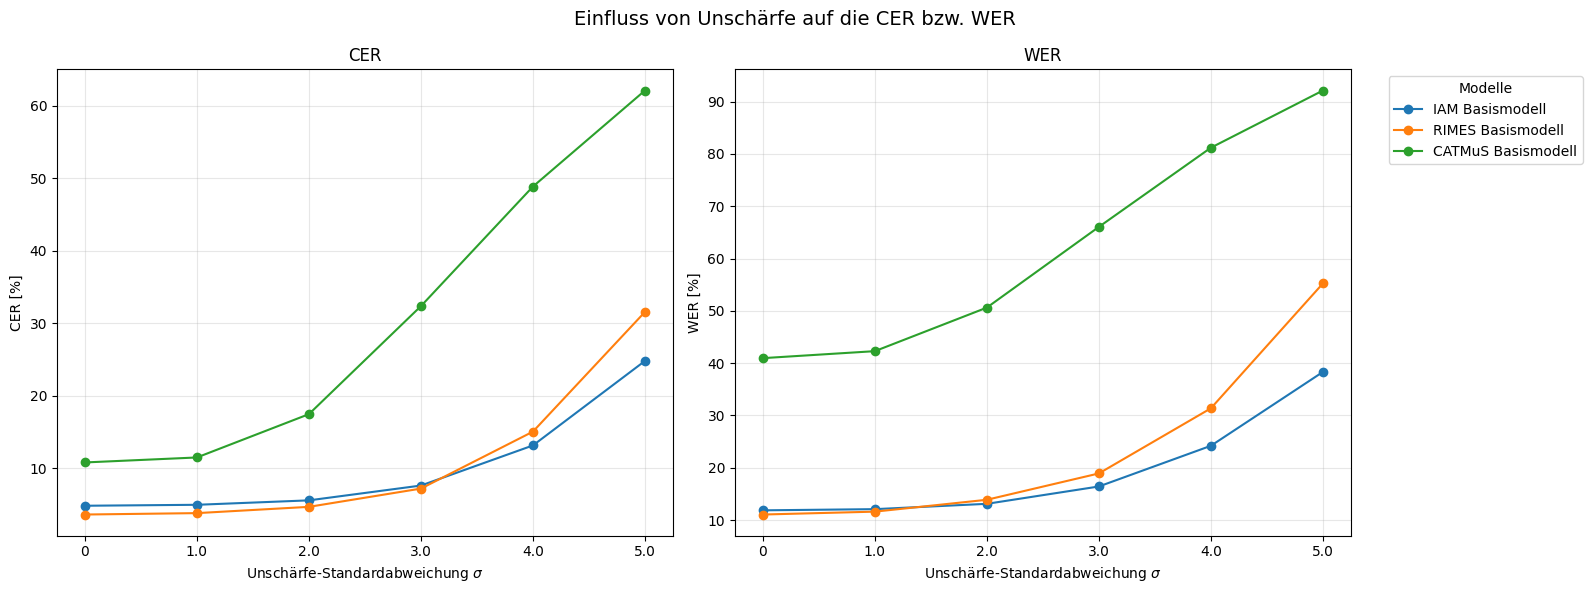

In [21]:
render_graph(
    "blur",
    "matched",
    title="Einfluss von Unschärfe auf die CER bzw. WER",
    x_label=r"Unschärfe-Standardabweichung $\sigma$",
)

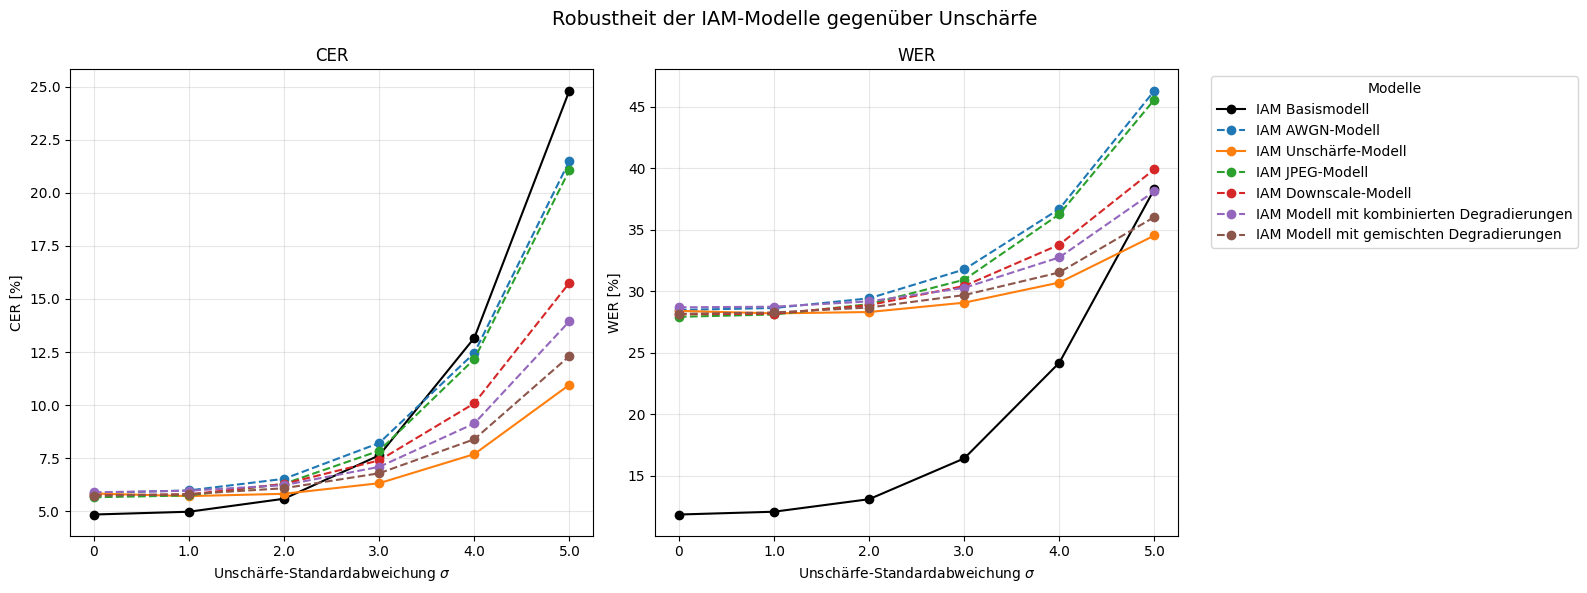

In [6]:
render_graph(
    "blur",
    "iam",
    title="Robustheit der IAM-Modelle gegenüber Unschärfe",
    x_label=r"Unschärfe-Standardabweichung $\sigma$",
)

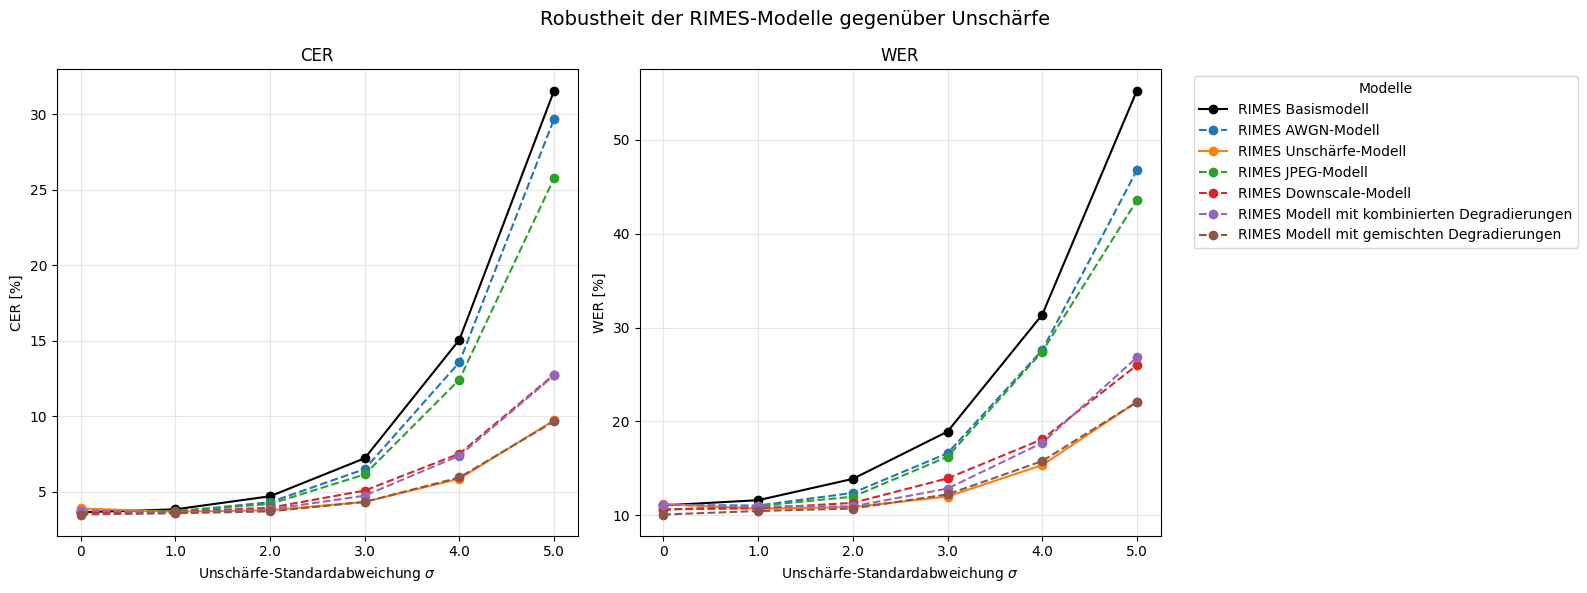

In [7]:
render_graph(
    "blur",
    "rimes",
    title="Robustheit der RIMES-Modelle gegenüber Unschärfe",
    x_label=r"Unschärfe-Standardabweichung $\sigma$",
)

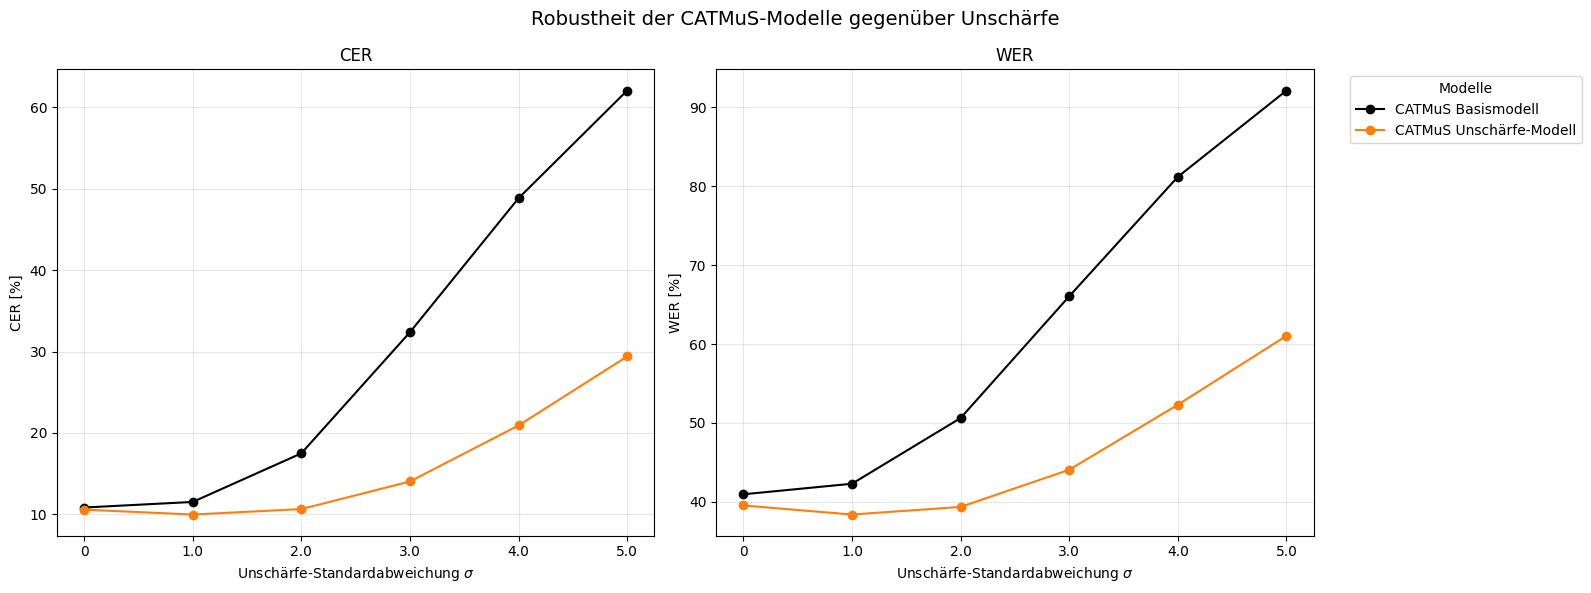

In [5]:
render_graph(
    "blur",
    "catmus",
    title="Robustheit der CATMuS-Modelle gegenüber Unschärfe",
    x_label=r"Unschärfe-Standardabweichung $\sigma$",
)

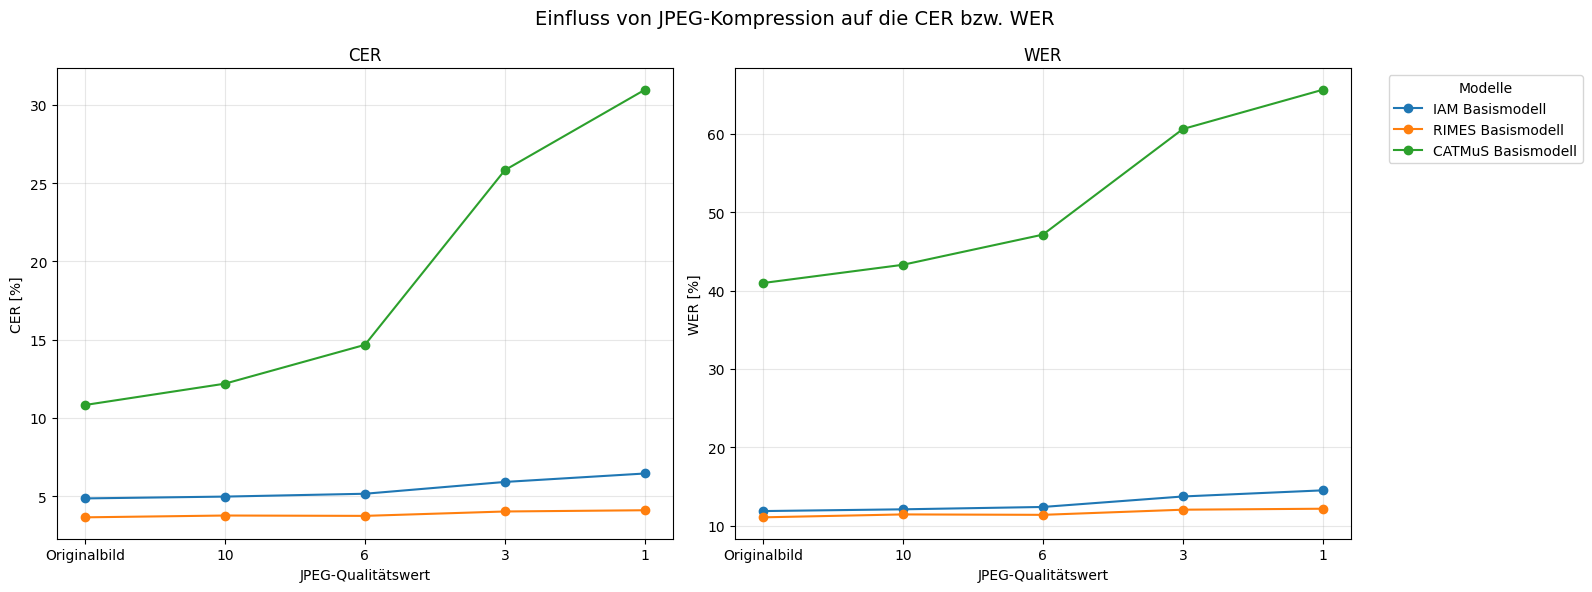

In [22]:
render_graph(
    "jpeg_compression",
    "matched",
    title="Einfluss von JPEG-Kompression auf die CER bzw. WER",
    x_label="JPEG-Qualitätswert",
)

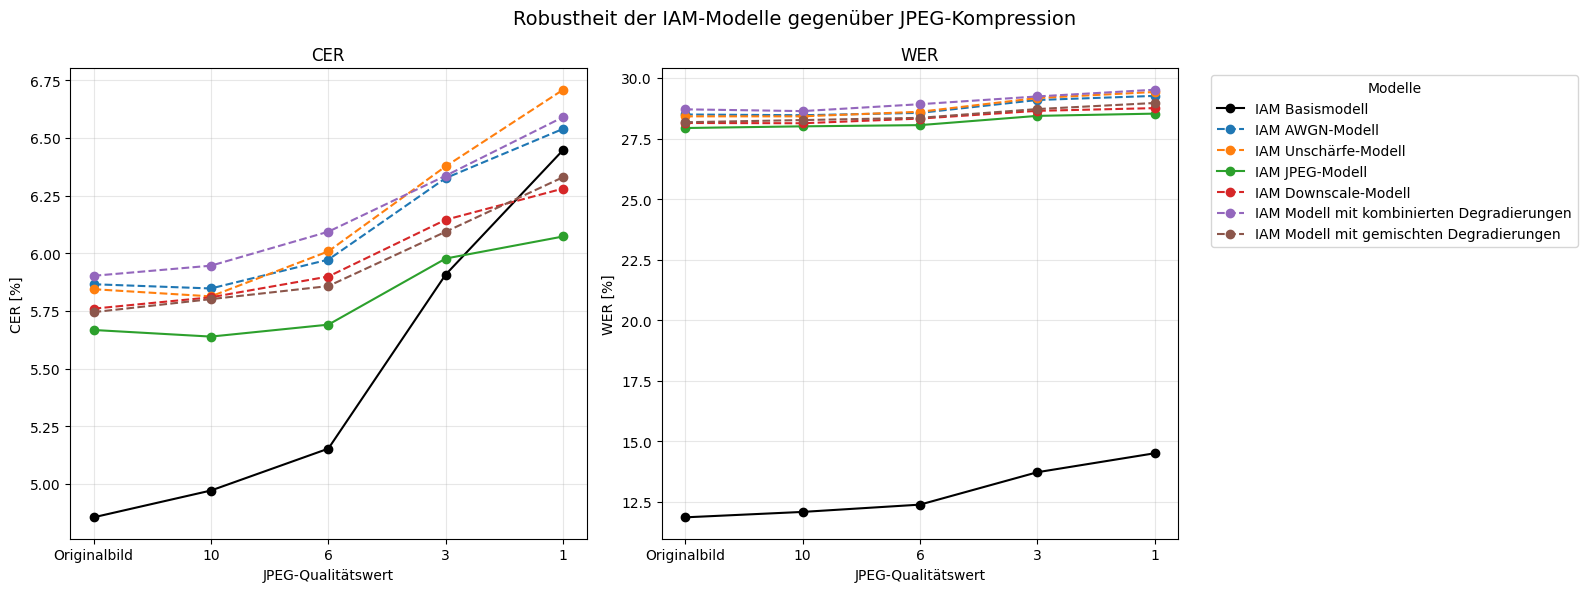

In [8]:
render_graph(
    "jpeg_compression",
    "iam",
    title="Robustheit der IAM-Modelle gegenüber JPEG-Kompression",
    x_label="JPEG-Qualitätswert",
)

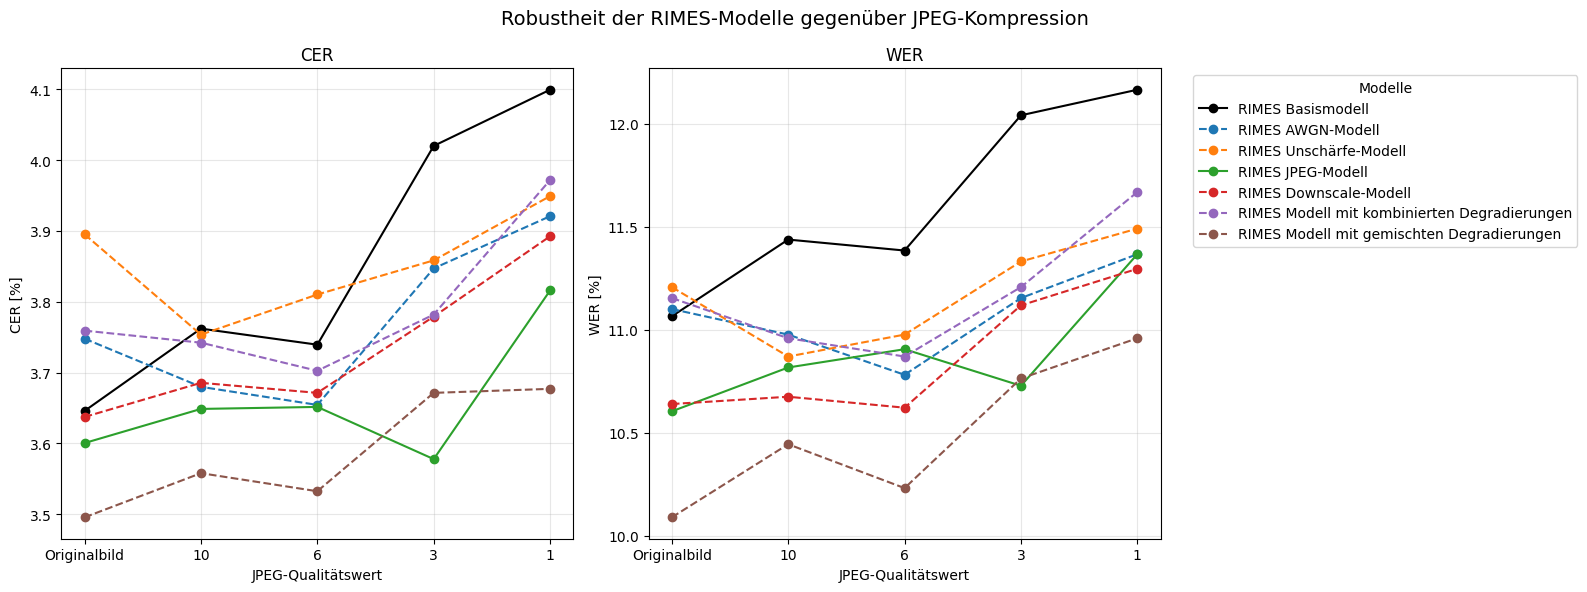

In [9]:
render_graph(
    "jpeg_compression",
    "rimes",
    title="Robustheit der RIMES-Modelle gegenüber JPEG-Kompression",
    x_label="JPEG-Qualitätswert",
)

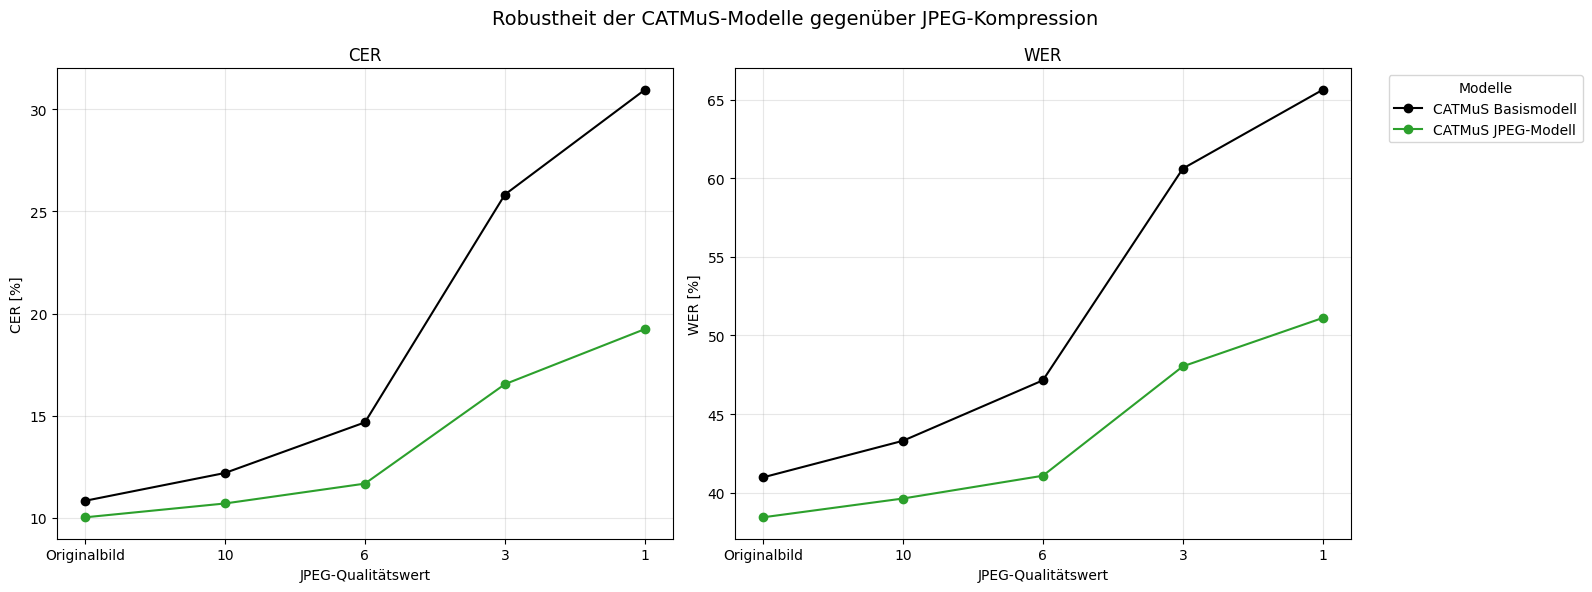

In [6]:
render_graph(
    "jpeg_compression",
    "catmus",
    title="Robustheit der CATMuS-Modelle gegenüber JPEG-Kompression",
    x_label="JPEG-Qualitätswert",
)

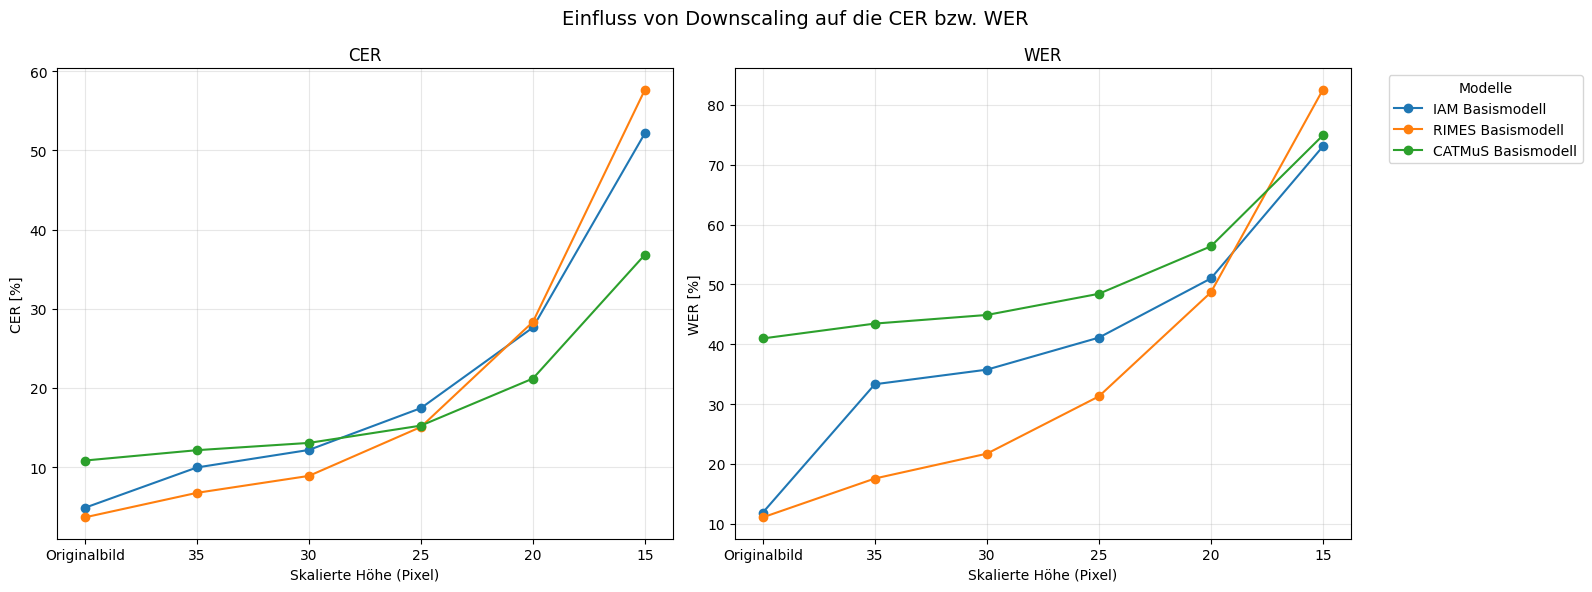

In [5]:
render_graph(
    "downscale",
    "matched",
    title="Einfluss von Downscaling auf die CER bzw. WER",
    x_label="Skalierte Höhe (Pixel)",
)

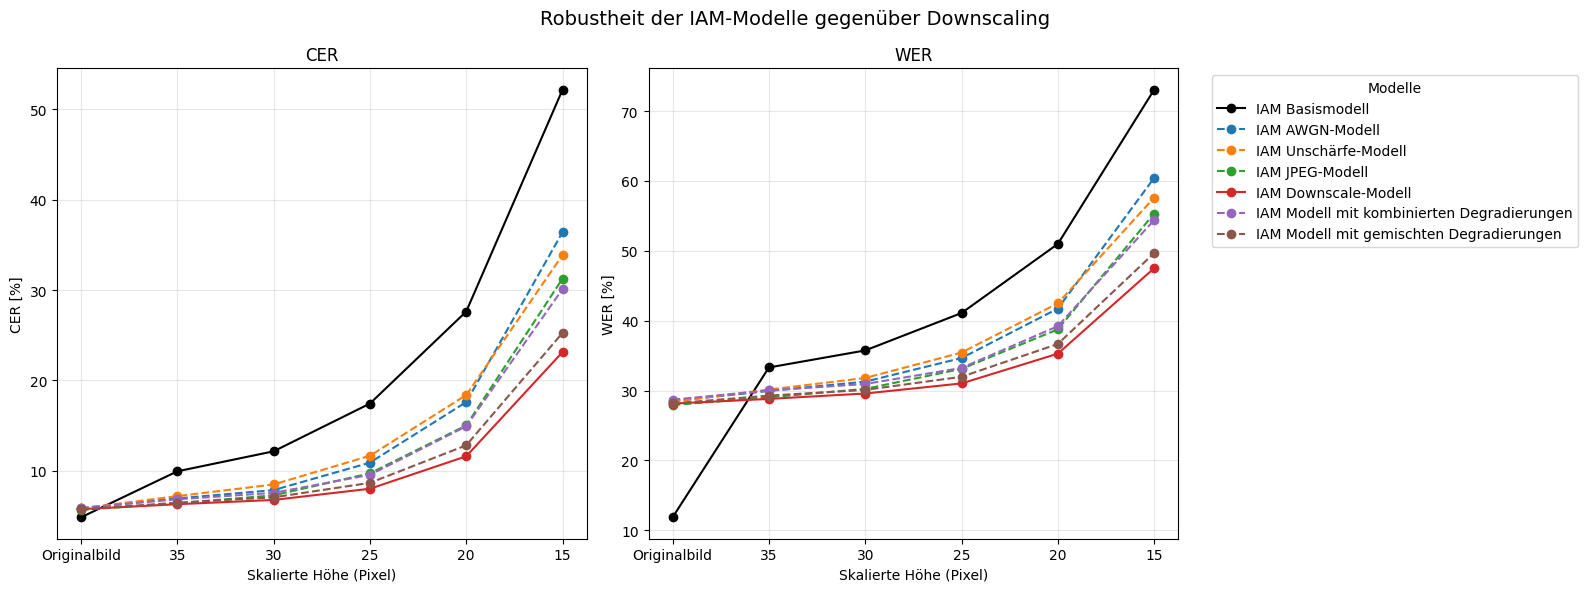

In [10]:
render_graph(
    "downscale",
    "iam",
    title="Robustheit der IAM-Modelle gegenüber Downscaling",
    x_label="Skalierte Höhe (Pixel)",
)

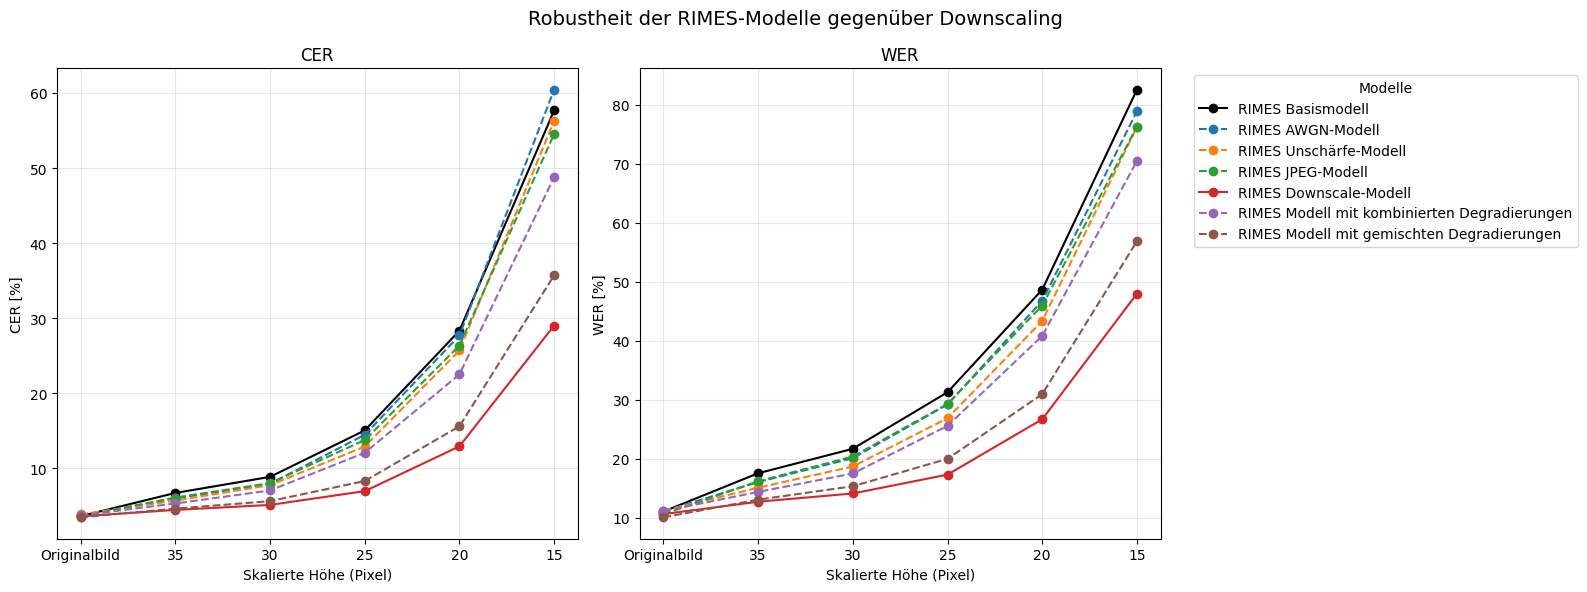

In [12]:
render_graph(
    "downscale",
    "rimes",
    title="Robustheit der RIMES-Modelle gegenüber Downscaling",
    x_label="Skalierte Höhe (Pixel)",
)

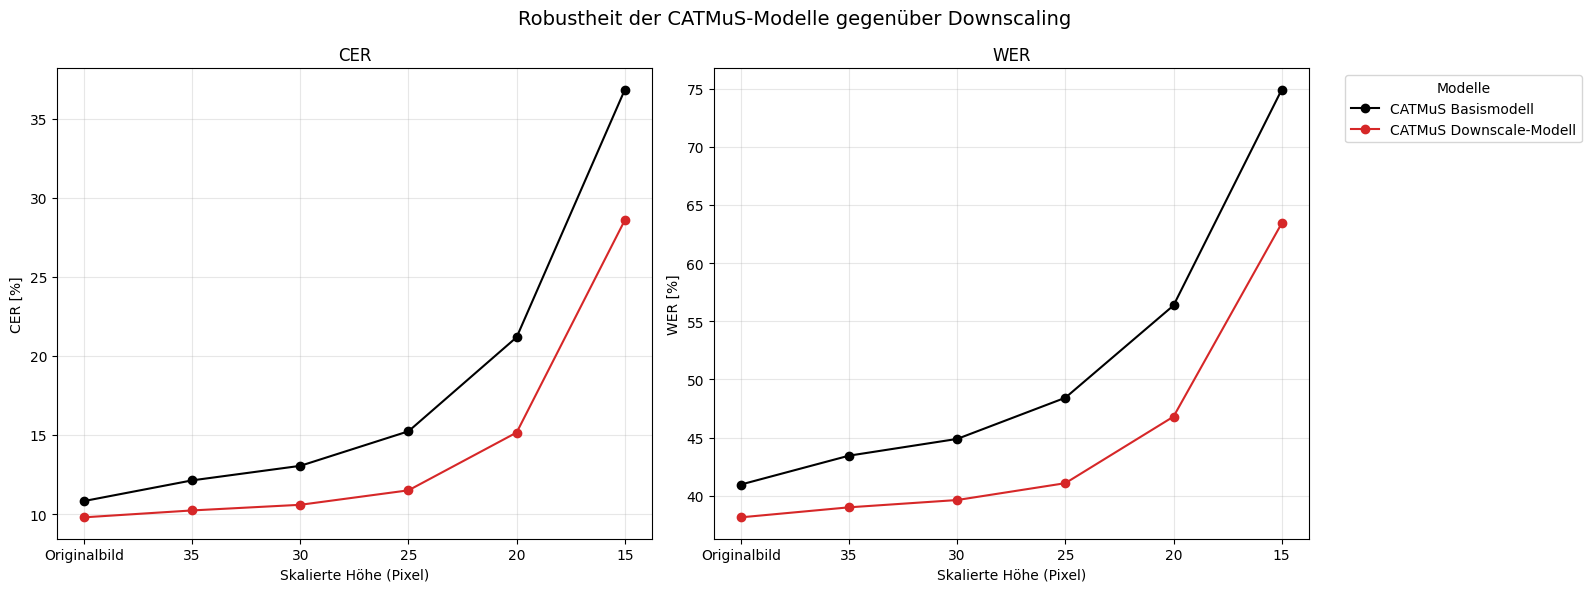

In [8]:
render_graph(
    "downscale",
    "catmus",
    title="Robustheit der CATMuS-Modelle gegenüber Downscaling",
    x_label="Skalierte Höhe (Pixel)",
)

## Result graphs for combined degradations

In [14]:
COMBO_LABELS = [
    r"$\sigma_{\mathrm{AWGN}} = 100$" + "\n" + r"$h = 30$",
    r"$\sigma_{\mathrm{Unschärfe}} = 2$" + "\n" + r"$h = 30$",
    r"$\sigma_{\mathrm{AWGN}} = 50$" + "\n" + r"$\sigma_{\mathrm{Unschärfe}} = 1$" + "\n" + r"$h = 30$",
    r"$\sigma_{\mathrm{AWGN}} = 100$" + "\n" + r"$\sigma_{\mathrm{Unschärfe}} = 2$" + "\n" + r"$h = 30$",
    r"$\sigma_{\mathrm{AWGN}} = 150$" + "\n" + r"$\sigma_{\mathrm{Unschärfe}} = 3$" + "\n" + r"$h = 30$",
]

In [13]:
def render_combo_bars(
    group,
    title="Kombinierte Degradierungen",
    x_label="Degradierung"
):
    degradation = "combo"
    intensities = DEGRADATIONS[degradation]

    if len(COMBO_LABELS) != len(intensities):
        raise ValueError(
            "COMBO_LABELS muss genauso viele Einträge wie "
            "DEGRADATIONS['combo'] enthalten."
        )

    if group != "matched" and group not in MODELS:
        raise ValueError(
            f"Gruppe muss 'matched' oder eine der folgenden sein: "
            f"{list(MODELS.keys())}"
        )

    models_to_plot = []

    # --------------------------------------------------
    # Modelle auswählen
    # --------------------------------------------------

    if group == "matched":
        # Nur Basismodell jedes Datensatzes
        for dataset, models in MODELS.items():

            if "base" not in models:
                continue

            model, label = models["base"]

            models_to_plot.append({
                "model": model,
                "label": label,
                "color": DATASET_COLORS[dataset],
                "hatch": "",
            })

    else:
        # Alle Modelle des gewählten Datensatzes
        for model_type, (model, label) in MODELS[group].items():

            # Combo-Modell ohne Schraffierung,
            # alle anderen Modelle schraffiert
            if model_type == "combo":
                hatch = ""
            else:
                hatch = "//"

            models_to_plot.append({
                "model": model,
                "label": label,
                "color": MODEL_COLORS[model_type],
                "hatch": hatch,
            })

    # --------------------------------------------------
    # CER und WER nebeneinander
    # --------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    number_of_models = len(models_to_plot)

    x = np.arange(len(intensities))
    width = 0.8 / number_of_models

    for ax, metric in zip(axes, ["cer", "wer"]):

        for i, model_info in enumerate(models_to_plot):

            model_df = df[
                (df["method"] == degradation)
                & (df["model"] == model_info["model"])
            ].copy()

            if model_df.empty:
                continue

            model_df["intensity"] = pd.to_numeric(
                model_df["intensity"]
            )

            model_df = (
                model_df
                .set_index("intensity")
                .reindex(intensities)
            )

            values = model_df[metric] * 100

            offset = (
                i - (number_of_models - 1) / 2
            ) * width

            ax.bar(
                x + offset,
                values,
                width=width,
                label=model_info["label"],
                color=model_info["color"],
                hatch=model_info["hatch"],
                edgecolor="black"
            )

        ax.set_xticks(x)
        ax.set_xticklabels(COMBO_LABELS)

        ax.set_xlabel(x_label)
        ax.set_ylabel(f"{metric.upper()} [%]")
        ax.set_title(metric.upper())

        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title, fontsize=14)

    axes[1].legend(
        title="Modelle",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

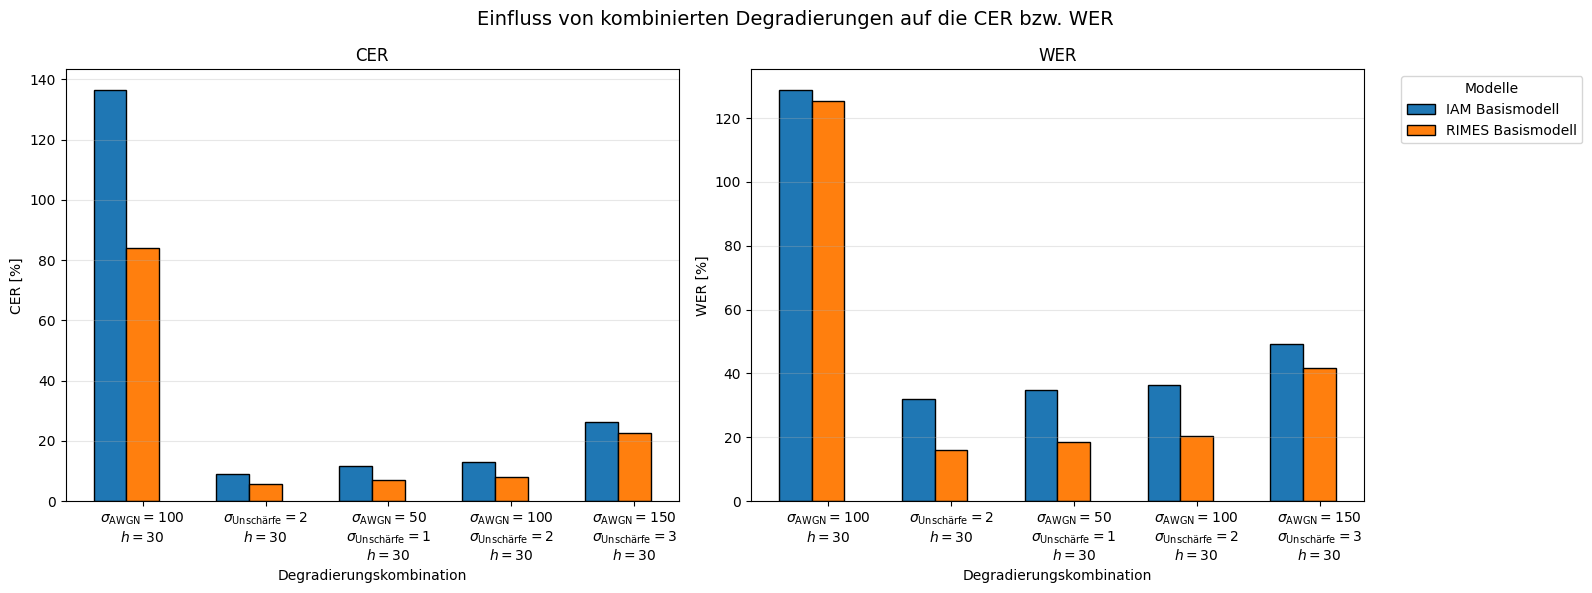

In [15]:
render_combo_bars(
    "matched",
    title="Einfluss von kombinierten Degradierungen auf die CER bzw. WER",
    x_label="Degradierungskombination"
)

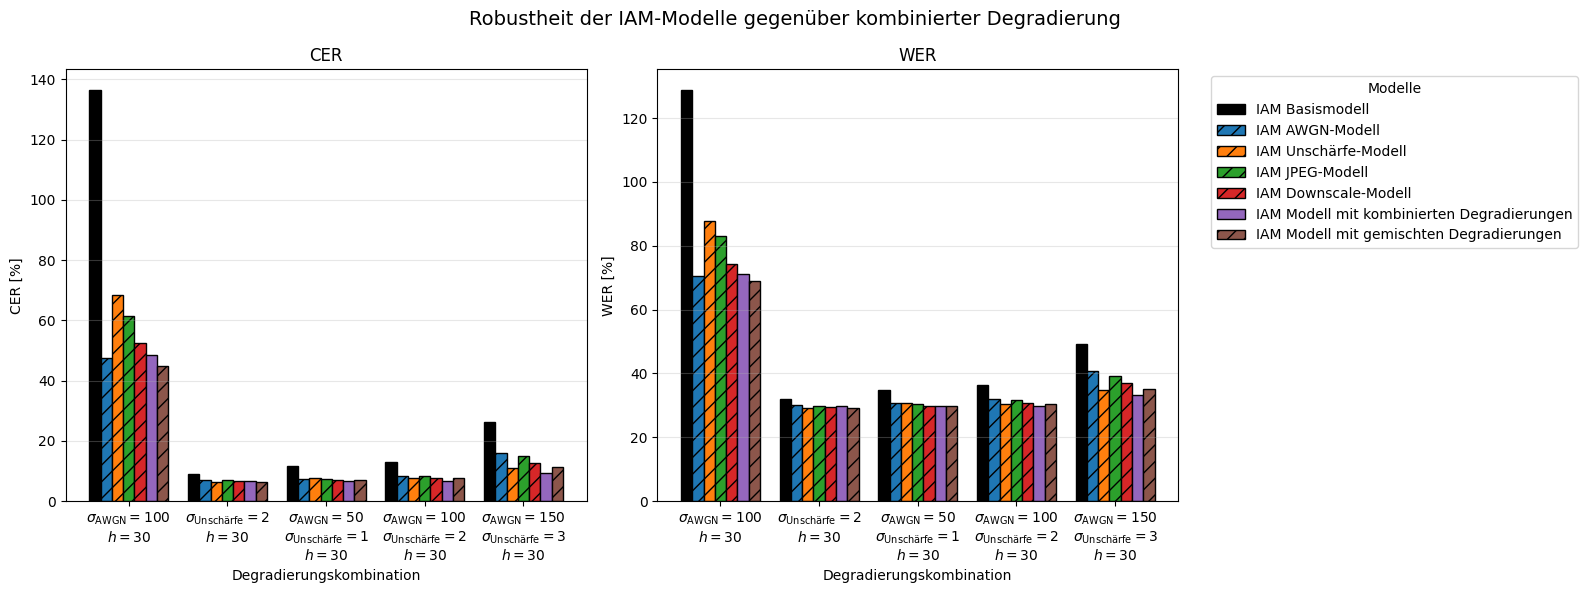

In [16]:
render_combo_bars(
    "iam",
    title="Robustheit der IAM-Modelle gegenüber kombinierter Degradierung",
    x_label="Degradierungskombination"
)

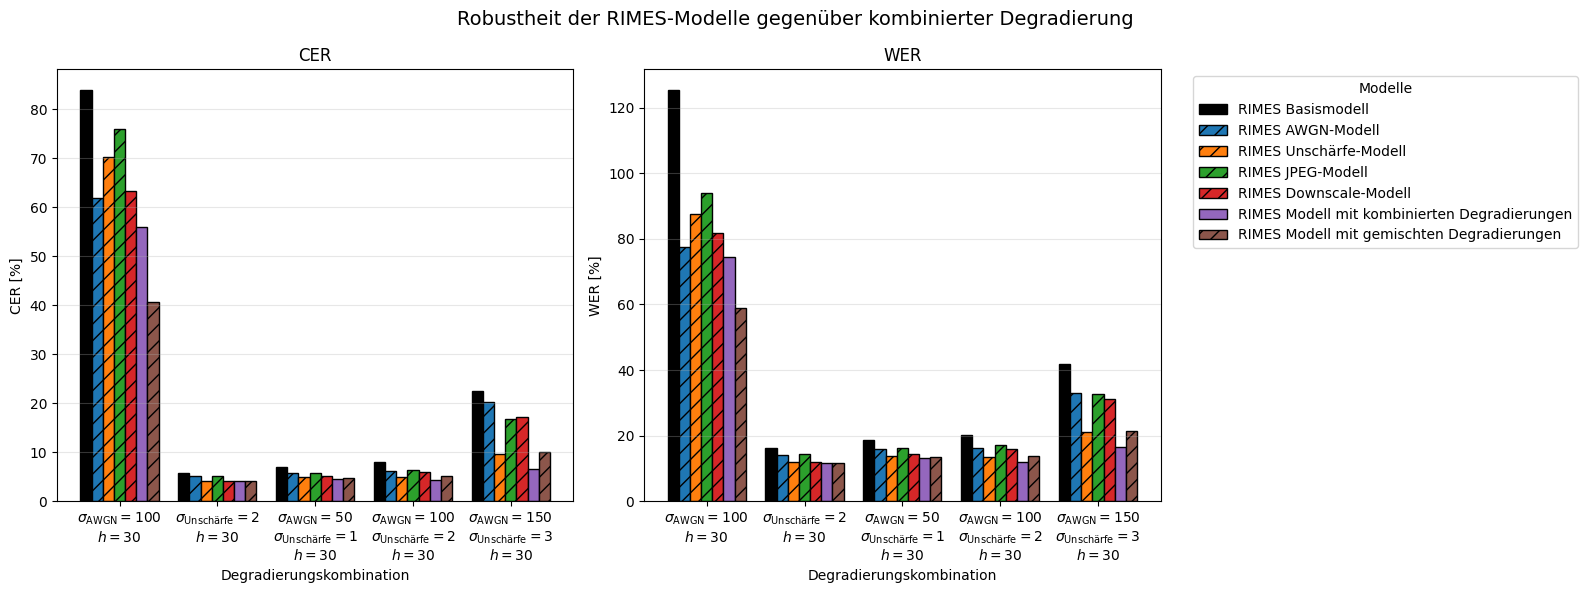

In [17]:
render_combo_bars(
    "rimes",
    title="Robustheit der RIMES-Modelle gegenüber kombinierter Degradierung",
    x_label="Degradierungskombination"
)